# 05 - Detect and Evaluate Injected Anomalies


## Notebook Objectives
- Run the residual-based anomaly detector using the tuned forecasting model.
- Fit anomaly thresholds on clean calibration data (`calibration_reference`) to keep threshold learning separate from evaluation data.
- Score the anomaly-injected dataset (`anomaly_injected`) and classify anomaly severity.
- Evaluate the configured high-alert baseline against injected ground truth.
- Compare alternative alert-routing policies, focusing on their ability to detect the injected label-drift episode earlier while limiting the resulting operational review burden.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root))

from config import (
    ANOMALY_EVAL_SUMMARY,
    ANOMALY_INJECTED_DATA,
    ANOMALY_RESULTS,
    ANOMALY_SCORE_PLOT,
    ANOMALY_THRESHOLDS,
    CALIBRATION_REFERENCE_DATA,
    RESULTS_DIR,
    TUNED_MODEL_PATH,
)
from src.anomaly.anomaly_detector import AnomalyDetector
from src.config_loader import load_anomaly_detection_policy, load_config
from src.features.utils import get_feature_columns
from src.models.io import load_model
from src.visualization.evaluation import summarize_detection_results
from src.visualization.plots import plot_detection_results

## Run the detector

We fit anomaly thresholds on `calibration_reference` (our clean reference for normal behavior), then score `anomaly_injected` against those thresholds. This keeps threshold-learning honest because it never sees injected anomalies.

In [2]:
model = load_model(TUNED_MODEL_PATH)
feature_cols = get_feature_columns()
time_col = "date"
target_col = "daily_trip_count"

cfg = load_config()
anomaly_policy = load_anomaly_detection_policy(cfg)

calibration_df = pd.read_csv(CALIBRATION_REFERENCE_DATA, parse_dates=[time_col])
eval_df = pd.read_csv(ANOMALY_INJECTED_DATA, parse_dates=[time_col])

X_calibration = calibration_df[feature_cols]
y_calibration = calibration_df[target_col]
X_eval = eval_df[feature_cols]
y_eval = eval_df[target_col]

y_calibration_pred = model.predict(X_calibration)
y_eval_pred = model.predict(X_eval)

detector = AnomalyDetector(
    quantiles=anomaly_policy["quantiles"],
    anomaly_levels=anomaly_policy["alert_levels"],
)
detector.fit(y_calibration.values, y_calibration_pred)
thresholds = detector.get_thresholds()
detection = detector.detect(y_eval.values, y_eval_pred)

print("Learned thresholds:")
for q_key, info in sorted(thresholds.items()):
    percentile = int(float(q_key) * 100)
    print(f"  Q{percentile} ({info['severity']}): {info['value']:.2f}")

Learned thresholds:
  Q90 (low): 5054.93
  Q95 (medium): 8253.10
  Q99 (high): 23769.00


## Evaluate against the injected ground truth

We evaluate the anomaly detector against the injected ground truth. As a baseline, we use a high-alert policy that flags any observation exceeding the high threshold. Since the injected anomalies are labelled, we can directly calculate precision, recall, and F1 score.

In [3]:
results_df = eval_df[[time_col]].copy()
results_df["actual"] = y_eval.values
results_df["predicted"] = y_eval_pred
results_df["score"] = detection["score"].values
results_df["severity"] = detection["severity"].values
results_df["is_anomaly"] = detection["is_anomaly"].values
results_df["true_anomaly"] = eval_df["true_anomaly"].values
results_df["true_anomaly_type"] = eval_df["true_anomaly_type"].values
results_df["anomaly_id"] = eval_df["anomaly_id"].values

summary = summarize_detection_results(results_df)

print("Evaluation summary:")
print(f"  TP: {summary['tp']} | FP: {summary['fp']} | FN: {summary['fn']}")
print(f"  Precision: {summary['precision']:.3f}")
print(f"  Recall:    {summary['recall']:.3f}")
print(f"  F1:        {summary['f1']:.3f}")

if summary.get("by_type"):
    print("\nDetection by anomaly type (recall-centric):")
    for anomaly_type, metrics in summary["by_type"].items():
        print(
            f"  {anomaly_type}: recall={metrics['recall']:.3f}, "
            f"f1={metrics['f1']:.3f}, tp={metrics['tp']}, fn={metrics['fn']}"
        )

RESULTS_DIR.mkdir(exist_ok=True)
results_df.drop(columns="anomaly_id").to_csv(ANOMALY_RESULTS, index=False)

with open(ANOMALY_THRESHOLDS, "w") as f:
    json.dump(thresholds, f, indent=2)

with open(ANOMALY_EVAL_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

Evaluation summary:
  TP: 11 | FP: 1 | FN: 4
  Precision: 0.917
  Recall:    0.733
  F1:        0.815

Detection by anomaly type (recall-centric):
  label_drift: recall=0.600, f1=0.750, tp=6, fn=4
  spike_day: recall=1.000, f1=1.000, tp=3, fn=0
  zero_load: recall=1.000, f1=1.000, tp=2, fn=0


## Visualize detections and score thresholds

The chart shows the forecast residuals alongside the three severity thresholds.

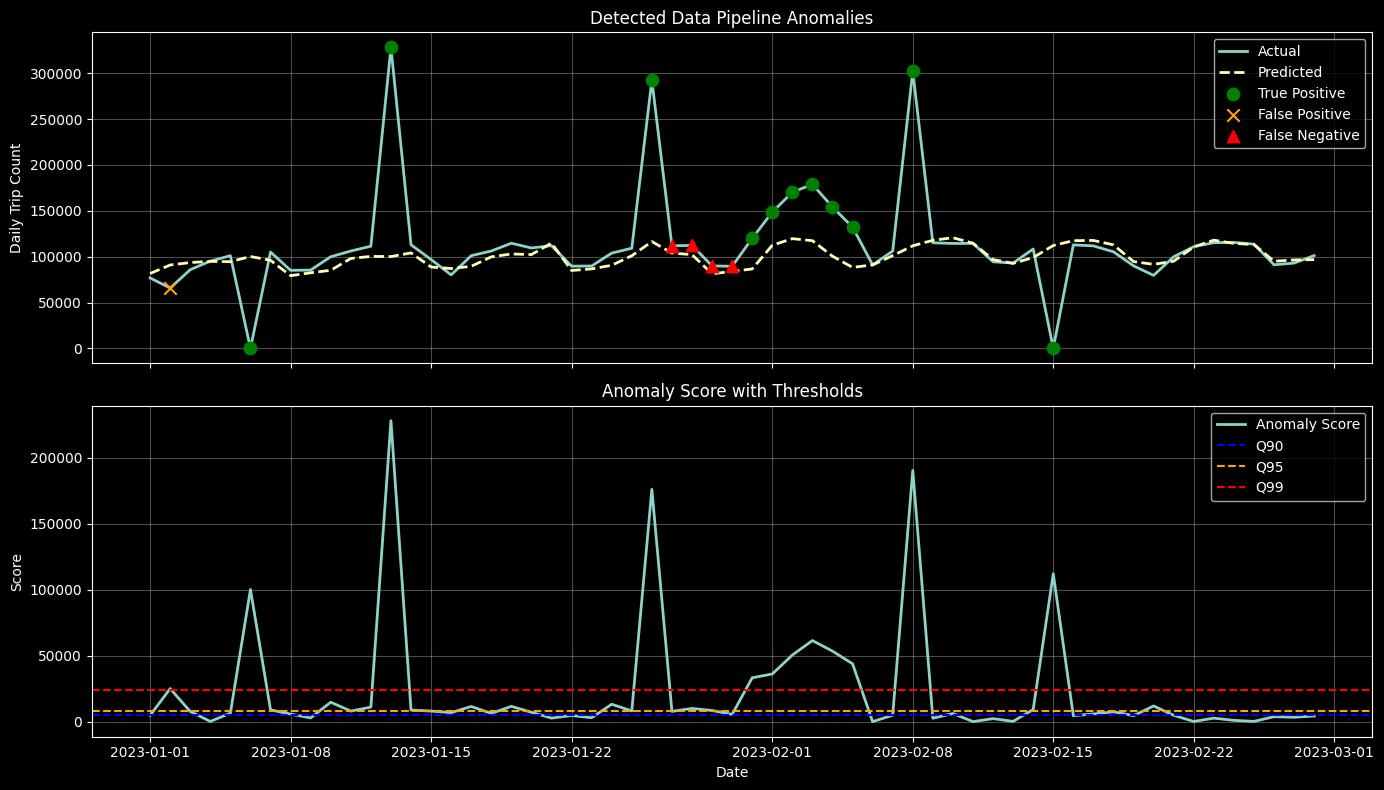

In [4]:
fig, axes = plot_detection_results(
    df_results=results_df,
    thresholds=thresholds,
    output_path=ANOMALY_SCORE_PLOT,
    show=True,
)

## Compare alert-routing policies

To isolate the effect of the routing policy, this proof of concept keeps the fitted detector fixed and varies only how its severity labels are routed.

The comparison focuses on the injected label-drift episode, where the high-alert baseline is expected to detect the developing anomaly only after its severity has increased sufficiently. The alternative policies are designed to investigate whether earlier operational detection can be achieved without creating excessive review burden.

| Policy | Role |
| --- | --- |
| High-alert baseline | Immediate escalation for high-severity alerts, including zero-load and spike-day events. |
| High-or-medium policy | Increases sensitivity by escalating both high- and medium-severity alerts, illustrating the additional review burden of a lower alert threshold. |
| Two-day lower-severity drift watch | Opens a drift investigation after two consecutive low- or medium-severity signals. High alerts remain immediate and are handled separately. |

For the label-drift episode, we report whether the policy detects the drift, the detection latency in calendar days, and the number of false alerts generated outside the injected anomaly.

These metrics highlight the trade-off between earlier detection of evolving anomalies and the additional operational review burden introduced by more sensitive routing policies.

In [6]:
def two_day_lower_severity_watch(df, date_col):
    ordered = df[[date_col, "severity"]].sort_values(date_col).copy()
    candidate = ordered["severity"].isin(["low", "medium"])
    previous_date = ordered[date_col].shift()
    consecutive = candidate & candidate.shift(fill_value=False) & (
        (ordered[date_col] - previous_date).dt.days.eq(1)
    )

    ordered["drift_watch"] = consecutive
    return ordered["drift_watch"].reindex(df.index, fill_value=False)


def drift_detection_outcome(df, alert_flag, date_col):
    drift = df.loc[df["true_anomaly_type"].eq("label_drift")].sort_values(date_col)

    if drift["anomaly_id"].nunique() != 1:
        raise ValueError("Policy comparison expects exactly one label-drift episode.")

    start_date = drift[date_col].iloc[0]
    alert_dates = drift.loc[alert_flag.loc[drift.index], date_col]
    drift_detected = not alert_dates.empty

    return {
        "drift_detected": drift_detected,
        "detection_latency_days": (
            (alert_dates.iloc[0] - start_date).days if drift_detected else None
        ),
    }


policy_definitions = {
    "High-alert baseline": {
        "role": "Immediate extreme-event escalation",
        "alerts": results_df["severity"].eq("high"),
    },
    "High-or-medium policy": {
        "role": "Sensitivity comparison",
        "alerts": results_df["severity"].isin(["medium", "high"]),
    },
    "Two-day lower-severity drift watch": {
        "role": "Drift investigation",
        "alerts": two_day_lower_severity_watch(results_df, time_col),
    },
}

if not policy_definitions["High-alert baseline"]["alerts"].equals(
    results_df["is_anomaly"]
):
    raise AssertionError("High-alert baseline must match the configured policy.")

policy_rows = []
for policy_name, definition in policy_definitions.items():
    alert_flag = definition["alerts"]
    drift_outcome = drift_detection_outcome(results_df, alert_flag, time_col)
    false_alerts = int((alert_flag & results_df["true_anomaly"].eq(0)).sum())

    policy_rows.append(
        {
            "policy": policy_name,
            "role": definition["role"],
            **drift_outcome,
            "false_alerts": false_alerts,
        }
    )

policy_comparison = pd.DataFrame(policy_rows)
policy_comparison["detection_latency_days"] = (
    policy_comparison["detection_latency_days"].fillna("not detected")
)
display(policy_comparison)

,policy,role,drift_detected,detection_latency_days,false_alerts
0,High-alert baseline,Immediate extreme-event escalation,True,4,1
1,High-or-medium policy,Sensitivity comparison,True,1,10
2,Two-day lower-severity drift watch,Drift investigation,True,1,11


## Interpretation

- The high-alert baseline reliably detects extreme anomalies: both **zero-load** and **spike-day** anomalies achieve 100% recall. In contrast, recall for the gradually developing **label-drift** anomaly is only 60%, highlighting the limitation of relying on high-severity alerts alone for evolving anomalies.
- In the injected label-drift episode, the high-alert baseline raises its first alert after four days. Both alternative routing policies reduce the detection latency to one day, demonstrating the potential benefit of incorporating lower-severity signals into the routing logic.
- The **high-or-medium policy** achieves the same one-day detection latency but generates 17 false alerts. The **two-day lower-severity drift watch** reaches the same latency with only 5 false alerts, providing a substantially better trade-off between earlier drift detection and operational review burden in this proof of concept.
- These results support a two-layer routing concept: high-severity alerts can continue to trigger immediate escalation for extreme events, while persistent lower-severity signals can be used to open a separate drift investigation.
- The results are based on a single synthetic label-drift episode and injected anomalies. The specific thresholds, persistence requirement, and acceptable false-alert burden should therefore be calibrated against real operating data and actual review capacity before production use.